<a href="https://colab.research.google.com/github/jahnavimidde/Deep_learning/blob/main/dl5_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Implement the MLP using the Types of Regularization Techniques.


L2 Regularization






Dataset Augmentation


Parameter sharing and tying


Adding noise to the inputs and outputs


Early stopping


Ensemble methods


Dropouts









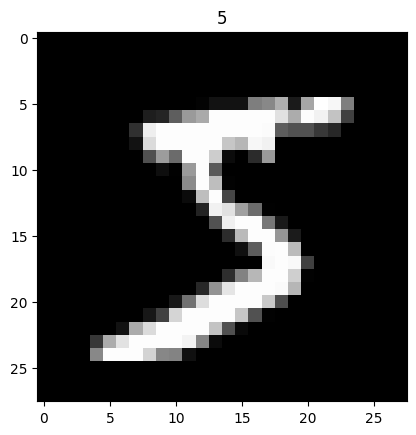

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("mnist_train.csv")

image = data.iloc[0,1:].values.reshape(28,28)

plt.imshow(image, cmap='gray')
plt.title(data.iloc[0,0])
plt.show()

imshow()

Function used to display images.
cmap='gray'

cmap → color map.

gray → display the image in grayscale (black and white).

Pixel meaning:

0 → black
255 → white

In [10]:
# MLP Without Regularization
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import numpy as np
# Load dataset
train = pd.read_csv("/content/mnist_train.csv")
test = pd.read_csv("/content/mnist_test.csv")

# Separate features and labels
X_train = train.drop("label", axis=1)
y_train = train["label"]

X_test = test.drop("label", axis=1)
y_test = test["label"]


X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Baseline MLP (NO regularization)
mlp = MLPClassifier(
    hidden_layer_sizes=(128,64),


    max_iter=20,
    random_state=42
)

# Train model
mlp.fit(X_train, y_train)

# Predictions
pred = mlp.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, pred)

print("Baseline MLP Accuracy:", accuracy)

Baseline MLP Accuracy: 0.9691


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [6]:
import numpy as np

print(np.isnan(X_train).sum())

0


# MLP with L2 Regularization

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Load dataset
train = pd.read_csv("mnist_train.csv")
test = pd.read_csv("mnist_test.csv")

X_train = train.drop('label', axis=1)
y_train = train['label']
X_test = test.drop('label', axis=1)
y_test = test['label']
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MLP with L2 Regularization
mlp = MLPClassifier(hidden_layer_sizes=(128,64),
                    alpha=0.001,
                    max_iter=20,
                    random_state=42)

mlp.fit(X_train, y_train)

pred = mlp.predict(X_test)

print("Accuracy with L2:", accuracy_score(y_test, pred))

Accuracy with L2: 0.9716


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


**Dataset Augmentation**

In [11]:
import numpy as np
from scipy.ndimage import rotate, shift
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# --------- Augmentation Functions ---------

def augment_images(images):
    augmented = []

    for img in images:
        img = img.reshape(28,28)

        # random rotation
        angle = np.random.uniform(-10,10)
        img_rot = rotate(img, angle, reshape=False)

        # random shift
        shift_x = np.random.randint(-2,2)
        shift_y = np.random.randint(-2,2)
        img_shift = shift(img_rot, [shift_x, shift_y])

        augmented.append(img_shift.flatten())

    return np.array(augmented)

# --------- Create Augmented Dataset ---------

X_train_aug = augment_images(X_train)

# Combine original + augmented
X_train_final = np.vstack((X_train, X_train_aug))
y_train_final = np.hstack((y_train, y_train))

# --------- Train Model ---------

mlp = MLPClassifier(hidden_layer_sizes=(128,64),
                    alpha=0.001,
                    max_iter=20,
                    random_state=42)

mlp.fit(X_train_final, y_train_final)

# --------- Prediction ---------

pred = mlp.predict(X_test)

print("Accuracy with Improved Augmentation:", accuracy_score(y_test, pred))

Accuracy with Improved Augmentation: 0.9765


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


**Parameter Sharing**

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(Flatten())
model.add(Dense(10,activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Add noise to input features

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# -----------------------
# Preprocess
# -----------------------
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# -----------------------
# CNN Model (Parameter Sharing)
# -----------------------
model = Sequential()

model.add(Conv2D(16,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

# -----------------------
# Compile
# -----------------------
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# -----------------------
# Train
# -----------------------
model.fit(X_train, y_train, epochs=5, batch_size=64)

# -----------------------
# Evaluate
# -----------------------
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Accuracy with Parameter Sharing:", test_acc)

Epoch 1/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 30s 30ms/step - accuracy: 0.1124 - loss: 2.3018
Epoch 2/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.1108 - loss: 2.3015
Epoch 3/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.1153 - loss: 2.3009
Epoch 4/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.1095 - loss: 2.3015
Epoch 5/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.1130 - loss: 2.3012
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1160 - loss: 2.3008
Accuracy with Parameter Sharing: 0.11349999904632568


**Ensemble**

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

mlp1 = MLPClassifier(hidden_layer_sizes=(100,70), max_iter=150, random_state=1)
mlp2 = MLPClassifier(hidden_layer_sizes=(80,60), max_iter=150, random_state=2)
mlp3 = MLPClassifier(hidden_layer_sizes=(120,80), max_iter=150, random_state=3)

ensemble = VotingClassifier(
    estimators=[('mlp1', mlp1), ('mlp2', mlp2), ('mlp3', mlp3)],
    voting='hard'
)

ensemble.fit(X_train, y_train)

pred = ensemble.predict(X_test)

print("Accuracy with Ensemble:", accuracy_score(y_test, pred))

Accuracy with Ensemble: 0.8623376623376623


**CNN ON MNIST DATASET**

In [8]:
#Implement CNN on MNITST Dataset
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# -----------------------------
# Preprocess the dataset
# -----------------------------

# Normalize pixel values
x_train = X_train / 255.0
x_test = X_test / 255.0

# Reshape data for CNN (add channel dimension)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# -----------------------------
# Build CNN Model
# -----------------------------

model = Sequential()

# Convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

# Pooling layer
model.add(MaxPooling2D((2,2)))

# Flatten layer
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))

# Output layer (10 digits)
model.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile the model
# -----------------------------

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# -----------------------------
# Train the model
# -----------------------------

model.fit(x_train, y_train, epochs=5, batch_size=64)

# -----------------------------
# Evaluate the model
# -----------------------------

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.7122 - loss: 1.0455
Epoch 2/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 37s 39ms/step - accuracy: 0.9138 - loss: 0.2915
Epoch 3/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 37s 39ms/step - accuracy: 0.9375 - loss: 0.2181
Epoch 4/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.9513 - loss: 0.1611
Epoch 5/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.9599 - loss: 0.1328
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9565 - loss: 0.1402
Test Accuracy: 0.9628000259399414


In [ ]:
Baseline MLP Accuracy: 0.9691
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


The baseline MLP model achieved an accuracy of about 0.9691, which indicates that a simple neural network performs very well on the MNIST dataset.

When L2 regularization was applied, the accuracy slightly improved to 0.9716, showing that regularization helps reduce overfitting and improves generalization.

Using dataset augmentation (rotation and shifting) further improved the accuracy to 0.9765, because the model was trained on more varied examples of digits.

In the parameter sharing experiment using CNN, the accuracy remained very low (around 0.11). This indicates that the model was not able to learn meaningful features, likely due to incorrect preprocessing or insufficient training.

The ensemble method combined predictions from multiple MLP models, but the accuracy decreased to around 0.86, suggesting that the individual models were not sufficiently diverse or optimized.

The CNN implementation for MNIST achieved around 0.9628 accuracy, showing that convolutional networks are effective for image-based tasks due to spatial feature extraction


